#Road accidents analysis

##Project overview

This project analyzes road traffic accidents to determine patterns related to crash timing, weather conditions, crash types and contributing factors. The goal is to discover key insights that can help improve road safety and reduce accident risks.

##Objectives

1. Analyze crash patterns by time and day.
2. Identify the most common crash types.
3. Explore the main contributing factors behind accidents.
4. Analyze factors associated with fatal injuries.
5. Investigate the relationship between weather conditions and crash frequency.

##Data cleaning

1. Removed duplicate records.
2. Converted crash_date to datetime format.
3. Checked data types.
4. Checked for missing values.

In [3]:
import pandas as pd
import numpy as np
import plotly.express as px

In [4]:
df=pd.read_csv("traffic_accidents.csv")
df.head()

,crash_date,traffic_control_device,weather_condition,lighting_condition,first_crash_type,trafficway_type,alignment,roadway_surface_cond,road_defect,crash_type,...,most_severe_injury,injuries_total,injuries_fatal,injuries_incapacitating,injuries_non_incapacitating,injuries_reported_not_evident,injuries_no_indication,crash_hour,crash_day_of_week,crash_month
0,07/29/2023 01:00:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,TURNING,NOT DIVIDED,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,13,7,7
1,08/13/2023 12:11:00 AM,TRAFFIC SIGNAL,CLEAR,"DARKNESS, LIGHTED ROAD",TURNING,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,2.0,0,1,8
2,12/09/2021 10:30:00 AM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,DRY,NO DEFECTS,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,10,5,12
3,08/09/2023 07:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,ANGLE,FOUR WAY,STRAIGHT AND LEVEL,DRY,NO DEFECTS,INJURY AND / OR TOW DUE TO CRASH,...,NONINCAPACITATING INJURY,5.0,0.0,0.0,5.0,0.0,0.0,19,4,8
4,08/19/2023 02:55:00 PM,TRAFFIC SIGNAL,CLEAR,DAYLIGHT,REAR END,T-INTERSECTION,STRAIGHT AND LEVEL,UNKNOWN,UNKNOWN,NO INJURY / DRIVE AWAY,...,NO INDICATION OF INJURY,0.0,0.0,0.0,0.0,0.0,3.0,14,7,8


In [5]:
df.shape

(209306, 24)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 209306 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209306 non-null  object 
 1   traffic_control_device         209306 non-null  object 
 2   weather_condition              209306 non-null  object 
 3   lighting_condition             209306 non-null  object 
 4   first_crash_type               209306 non-null  object 
 5   trafficway_type                209306 non-null  object 
 6   alignment                      209306 non-null  object 
 7   roadway_surface_cond           209306 non-null  object 
 8   road_defect                    209306 non-null  object 
 9   crash_type                     209306 non-null  object 
 10  intersection_related_i         209306 non-null  object 
 11  damage                         209306 non-null  object 
 12  prim_contributory_cause       

In [7]:
df.isnull().sum()

crash_date                       0
traffic_control_device           0
weather_condition                0
lighting_condition               0
first_crash_type                 0
trafficway_type                  0
alignment                        0
roadway_surface_cond             0
road_defect                      0
crash_type                       0
intersection_related_i           0
damage                           0
prim_contributory_cause          0
num_units                        0
most_severe_injury               0
injuries_total                   0
injuries_fatal                   0
injuries_incapacitating          0
injuries_non_incapacitating      0
injuries_reported_not_evident    0
injuries_no_indication           0
crash_hour                       0
crash_day_of_week                0
crash_month                      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(31)

In [9]:
df=df.drop_duplicates()

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 209275 entries, 0 to 209305
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   crash_date                     209275 non-null  object 
 1   traffic_control_device         209275 non-null  object 
 2   weather_condition              209275 non-null  object 
 3   lighting_condition             209275 non-null  object 
 4   first_crash_type               209275 non-null  object 
 5   trafficway_type                209275 non-null  object 
 6   alignment                      209275 non-null  object 
 7   roadway_surface_cond           209275 non-null  object 
 8   road_defect                    209275 non-null  object 
 9   crash_type                     209275 non-null  object 
 10  intersection_related_i         209275 non-null  object 
 11  damage                         209275 non-null  object 
 12  prim_contributory_cause        2092

In [12]:
df["crash_date"].dtype

dtype('O')

In [13]:
df["crash_date"]=pd.to_datetime(df["crash_date"])

/var/folders/1q/wf1crwys39n8mf6w3br96sph0000gn/T/ipykernel_1447/585821803.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["crash_date"]=pd.to_datetime(df["crash_date"])


In [14]:
df["crash_date"].dtype

dtype('<M8[ns]')

In [15]:
df["crash_date"].min(),df["crash_date"].max()

(Timestamp('2013-03-03 16:48:00'), Timestamp('2025-01-18 00:17:00'))

In [16]:
df["most_severe_injury"].value_counts()

most_severe_injury
NO INDICATION OF INJURY     154767
NONINCAPACITATING INJURY     31521
REPORTED, NOT EVIDENT        16073
INCAPACITATING INJURY         6563
FATAL                          351
Name: count, dtype: int64

In [17]:
df["prim_contributory_cause"].value_counts().head(10)

prim_contributory_cause
UNABLE TO DETERMINE                       58310
FAILING TO YIELD RIGHT-OF-WAY             42909
FOLLOWING TOO CLOSELY                     19074
DISREGARDING TRAFFIC SIGNALS              14590
IMPROPER TURNING/NO SIGNAL                12642
FAILING TO REDUCE SPEED TO AVOID CRASH    10675
IMPROPER OVERTAKING/PASSING                8302
DISREGARDING STOP SIGN                     6746
IMPROPER LANE USAGE                        6460
NOT APPLICABLE                             5241
Name: count, dtype: int64

#Most Common Crash Types

This section identifies the types of road accidents that occur most frequently.

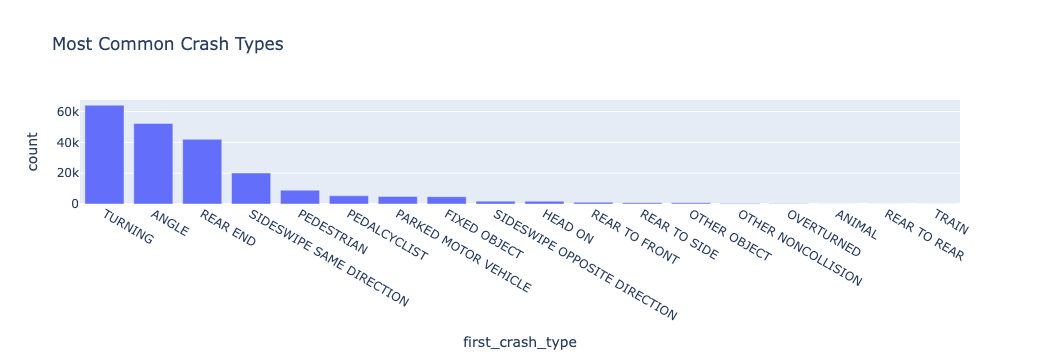

In [19]:
crash_types=df["first_crash_type"].value_counts().reset_index()
fig = px.bar(
   crash_types,
    x="first_crash_type",
    y="count",
title="Most Common Crash Types"
)
fig.show()

##Insight
The analysis focuses on the first crash type because it represents the initial collision mechanism. The result shows that turning is the most common crash type, followed by angle and rear end collisions. This indicates that these types of collisions account for a significant share of all recorded accidents.

#Number of Crashes by Hour.

This section explores at what time of day road accidents occurs most frequently.

In [24]:
hourly_crashes=df["crash_hour"].value_counts().sort_index().rename_axis("Hour").reset_index(name="Crashes")
hourly_crashes.columns=["Hour", "Crashes"]
hourly_crashes

,Hour,Crashes
0,0,4487
1,1,3729
2,2,3080
3,3,2364
4,4,2104
5,5,2819
6,6,4771
7,7,9405
8,8,11379
9,9,9298


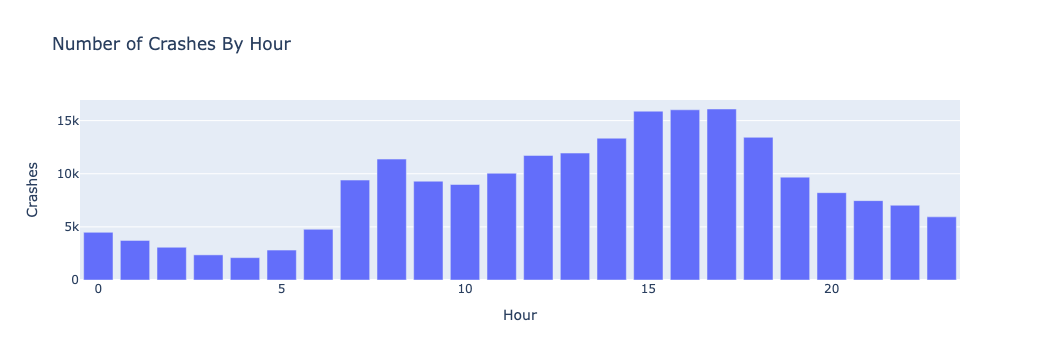

In [25]:
fig = px.bar(
    hourly_crashes,
    x="Hour",
    y="Crashes",
title="Number of Crashes By Hour"
)
fig.show()


#Insight
Most crashes occur during the time period from 15:00 to 17:00. This pattern may be related to increased traffic volume during the  end of the workday.

#Crashes by Day of Week
This section identifies which days of the week have the highest number of recorded crashes.

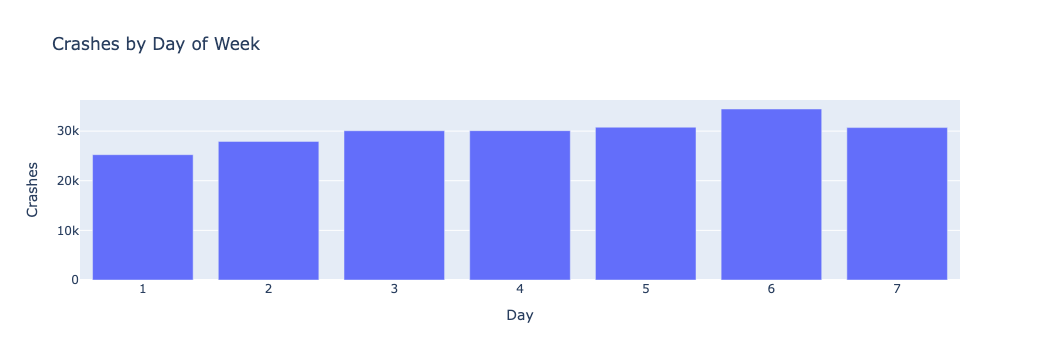

In [26]:
day_crashes=df["crash_day_of_week"].value_counts().sort_index().reset_index()
day_crashes.columns=["Day","Crashes"]
fig=px.bar(
    day_crashes,
    x="Day",
    y="Crashes",
    title="Crashes by Day of Week"
)
fig.show()

#Insight

The largest number of accidents occurs on Sunday. This may be related to increased travel activity and a higher number of events during the weekend.

#Top 10 Causes of Crashes

This section examines the most common causes that contribute to road crashes.

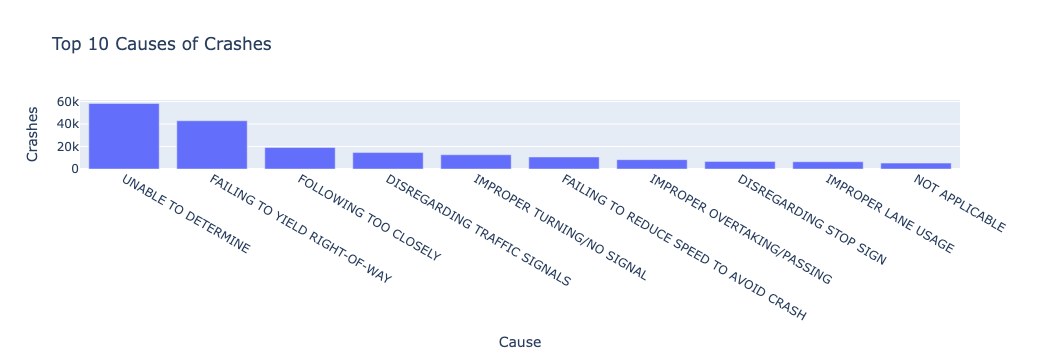

In [27]:
causes = df["prim_contributory_cause"].value_counts().head(10).reset_index()
causes.columns=["Cause","Crashes"]
fig=px.bar(
    causes,
    x="Cause",
    y="Crashes",
    title="Top 10 Causes of Crashes"
)
fig.show()

#Insight

The most frequent category is when the cause of the crash cannot be determined. The second most common cause is failure to yield the right-of-way.

#Top Causes of Fatal Crashes

This section identifies which causes most frequently lead to fatal crashes.

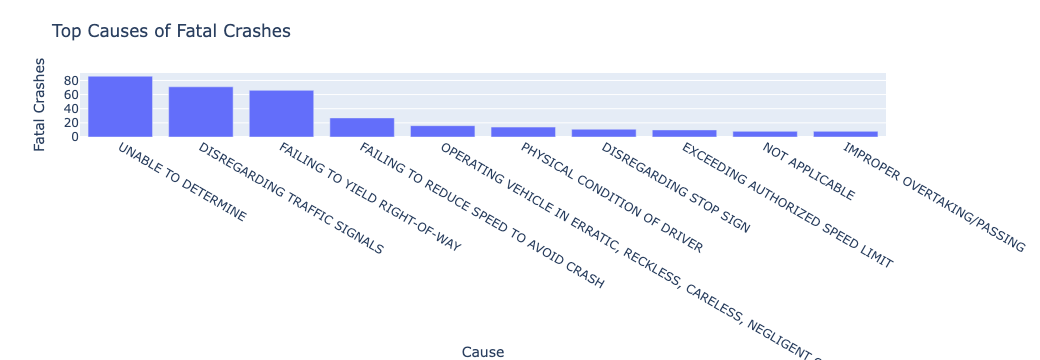

In [56]:
fatal_causes = (
    df[df["injuries_fatal"] > 0]
    ["prim_contributory_cause"]
    .value_counts()
    .head(10)
    .reset_index()
)

fatal_causes.columns = ["Cause", "Fatal Crashes"]

fatal_causes
fig=px.bar(
    fatal_causes,
    x="Cause",
    y="Fatal Crashes",
    title="Top Causes of Fatal Crashes"
)
fig.show()

#Insight

In most fatal crashes, the primary contributing cause was recorded as unknown or could not be determined. Among the identified causes, disregarding traffic signals was the second most common contributing factor.

#Crashes by Weather Conditions

This section explores how weather conditions affect the number of road accidents.

In [33]:
df["weather_condition"].value_counts()

weather_condition
CLEAR                       164673
RAIN                         21702
CLOUDY/OVERCAST               7532
SNOW                          6869
UNKNOWN                       6534
OTHER                          627
FREEZING RAIN/DRIZZLE          510
FOG/SMOKE/HAZE                 360
SLEET/HAIL                     308
BLOWING SNOW                   127
SEVERE CROSS WIND GATE          32
BLOWING SAND, SOIL, DIRT         1
Name: count, dtype: int64

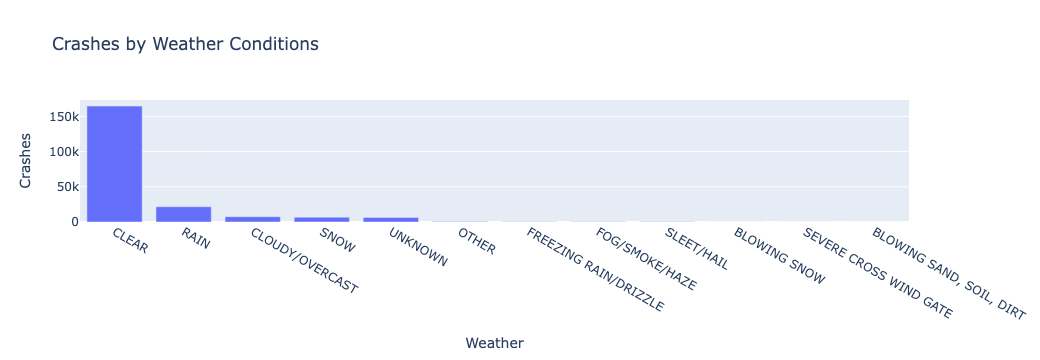

In [37]:
weather=df["weather_condition"].value_counts().reset_index()
weather.columns=["Weather","Crashes"]
fig=px.bar(
    weather,
    x="Weather",
    y="Crashes",
    title="Crashes by Weather Conditions"
)
fig.show()

#Insight

The largest number of crashes occurred during clear weather conditions. This suggests that most recorded accidents were not associated with adverse weather conditions. However, clear weather may also reflect higher traffic volume and more vehicles on the road.

#Fatalities by Crash Types

This section identifies which crash types most frequently result in fatal injuries.

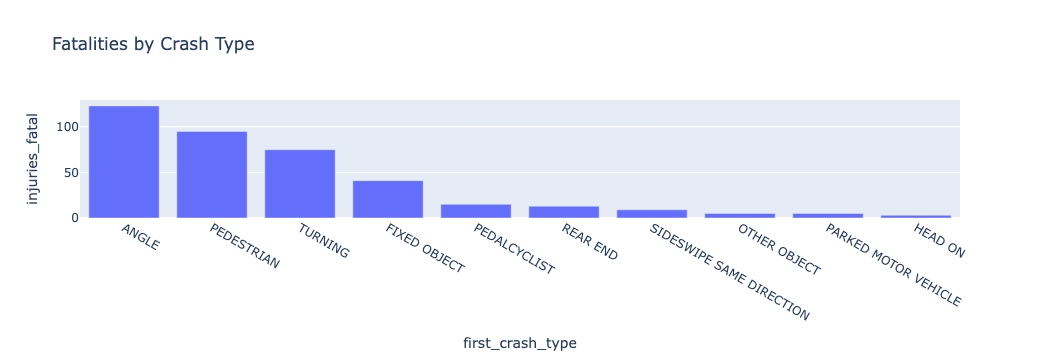

In [58]:
crash_severity=(
    df.groupby("first_crash_type")["injuries_fatal"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
)
crash_severity
fig=px.bar(
    crash_severity,
    x="first_crash_type",
    y="injuries_fatal",
    title="Fatalities by Crash Type"
)
fig.show()

#Insight

The results show that angle crashes resulted in the highest number of fatal injuries, followed by pedestrian crashes. This indicates that these types of collisions are associated with more severe consequences.

##Key Insights

1. The highest number of crashes occurred between 15:00 and 17:00, which may be related to increased traffic during afternoon commuting hours.
2. Saturday had the highest number of recorded crashes, possibly due to increased weekend travel activity.
3. The most common contributing causes were related to traffic violations and failure to yield right-of-way.
4. Clear weather conditions accounted for the largest number of crashes in the dataset.
5. Angle crashes resulted in the highest number of fatal injuries, followed by pedestrian crashes.